# 库导入

In [1351]:
#  库导入
import numpy as np # 数值数学计算库
from scipy.integrate import quad # 积分计算库

import matplotlib.pyplot as plt # 绘图库
from matplotlib.ticker import FuncFormatter # 图表格式化库

from typing import Tuple # 类型提示库
import pandas as pd # 使用pandas读取信息

from gapp import dgp

from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
import astropy.units as u
from astropy.cosmology import z_at_value

# 用于计算的理论函数区（计算器）

In [ ]:
# 计算ACDM模型下的红移与光度距离关系
def GW_calculate_ACDM(H0:float=67.64, Omega_M:float=0.3087, z=None, c:float=299792.458):
        """
        计算ACDM模型下的光度距离随红移的关系
        参数:
            H0       : 哈勃常数, km/s/Mpc
            Omega_M  : 物质密度参数
            n_points : 红移点数
            c        : 光速, km/s
        返回:
            z_vals  : 红移数组, numpy.ndarray
            dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
        """
        # 定义光度距离函数
        def d_L_em(z):
            def integrand(zp):
                return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
            integral, _ = quad(integrand, 0, z)
            return (1 + z) * (c / H0) * integral

        # 向量化函数
        d_L_em_vec = np.vectorize(d_L_em)

        # 红移数组
        z_vals = np.array(z)  # 确保 z 是 numpy 数组
        dL_vals = d_L_em_vec(z_vals)
        
        ACDM_theory_data = np.column_stack((z_vals, dL_vals))
        return ACDM_theory_data 

In [1353]:
# 计算RT模型下的红移与光度距离关系
def GW_calculate_RT(Xi:float=1.67, n:float=1.94, z=None, c:float=299792.458):
    data = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


# 用于画图的理论函数区

In [1354]:
# 计算ACDM模型下的红移与光度距离关系
# 输入：(ACDM模型参数 H0, Ωm, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：光度距离
def GW_forplot_ACDM(H0:float=67.64, Omega_M:float=0.3087, z_max:float=5, n_points:int=200, c:float=299792.458):
    """
    计算ACDM模型下的光度距离随红移的关系
    参数:
        H0       : 哈勃常数, km/s/Mpc
        Omega_M  : 物质密度参数
        z_max    : 红移最大值
        n_points : 红移点数
        c        : 光速, km/s
    返回:
        z_vals  : 红移数组, numpy.ndarray
        dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
    """
    # 定义光度距离函数
    def d_L_em(z):
        def integrand(zp):
            return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
        integral, _ = quad(integrand, 0, z)
        return (1 + z) * (c / H0) * integral

    # 向量化函数
    d_L_em_vec = np.vectorize(d_L_em)

    # 红移数组
    z_vals = np.linspace(0, z_max, n_points)
    dL_vals = d_L_em_vec(z_vals)
    
    ACDM_theory_data = np.column_stack((z_vals, dL_vals))
    return ACDM_theory_data 


In [1355]:
# 计算RT模型下的红移与光度距离关系
def GW_forplot_RT(Xi:float=1.67, n:float=1.94,z_max:float=5, n_points:int=200, c:float=299792.458):
    data = GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=z_max, n_points=n_points, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


# "实验"数据处理

In [1356]:
#  根据参数生成此高斯函数对应的 (x,y) 数据点 这里一共是400个点
# 输入：(均值，方差) -> 输出：对应高斯函数的点(x数组[]，y数组[]) NumPy 数组
def gaussian(mu: float, sigma2: float) -> Tuple[np.ndarray, np.ndarray]:
    sigma = np.sqrt(sigma2)
    x = np.linspace(mu - 5*sigma, mu + 5*sigma, 400) # 在中值和方差定义的范围内生成等距x值,共400个点
    y = (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp(- (x - mu)**2 / (2 * sigma2))
    return x, y

In [1357]:
# 根据高斯分布随机取点
# 输入：(均值，方差，采样点数) -> 输出：采样点数组sample[]  NumPy 数组
def sample_from_gaussian(mu: float, sigma2: float, n_samples: int = 1) -> np.ndarray:
    if mu == 0 and sigma2 == 0:
        return np.zeros(n_samples)
    x, y = gaussian(mu, sigma2)
    y_prob = y / y.sum()  # 将高斯函数值归一化为概率[这里是离散取点]，这里的y_prob也是一个数组
    samples = np.random.choice(x, size=n_samples, p=y_prob)  # 按概率抽样
    return samples

In [1358]:
# 数据CSV文件读取并输出
# 输入：CSV文件路径 -> 输出：原始数据的NumPy数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组

In [1359]:
# 读取CSV文件，生成随机样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def gaussianrandom_to_newnumpy(data:np.ndarray) -> np.ndarray:
    samples_list = []

    # 忽略第一列
    mu_values = data[:, 1]      # 第二列    
    sigma2_values = data[:, 2]  # 第三列    
    for mu, sigma2 in zip(mu_values, sigma2_values):
        sample = sample_from_gaussian(mu, sigma2,1)
        samples_list.append(sample[0])  # sample 是数组，取第0个元素
    samples_array = np.array(samples_list)

    new_data = np.column_stack((data[:, 0], samples_array, data[:, 2]))
    return new_data

In [1360]:
# 读取CSV文件，读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def ACDM_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z_values, c=299792.458)
    mu_values = data2[:,1]      # 第二列    
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [1361]:
# 读取CSV文件，读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def GT_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_RT(Xi=1.67, n=1.94, z=z_values, c=299792.458)
    mu_values = data2[:,1]     # 第二列
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [1362]:
# 使用GaPP方法处理二维数组
# 输入：(二维数组data_array[][], 以及模型参数) -> 输出：GaPP处理后的二维数组GaPP_data[][]
def gapp_solve(data:np.ndarray, xmin=0.0, xmax=10.0, nstar=200, initheta=[2.0,2.0]):
    """
    对输入数据 X,Y,Sigma 执行 Gaussian Process 重构
    
    返回：
    - Xstar: 重构函数对应横坐标
    - rec: 重构函数
    - drec: 一阶导数
    - d2rec: 二阶导数
    - d3rec: 三阶导数
    """
    X = data[:,0]
    Y = data[:,1]
    Sigma = data[:,2]

    # initialization of the Gaussian Process
    g = dgp.DGaussianProcess(X, Y, Sigma, cXstar=(xmin, xmax, nstar))

    # training of the hyperparameters and reconstruction of the function
    (rec, theta) = g.gp(theta=initheta)

    # reconstruction of the first, second and third derivatives.
    # theta is fixed to the previously determined value.
    (drec, theta) = g.dgp(thetatrain='False')
    (d2rec, theta) = g.d2gp()
    (d3rec, theta) = g.d3gp()
    
    # 用字典返回多个值
    result = {
        "X": X,
        "Y": Y,
        "Sigma": Sigma,
        "rec": rec,
        "drec": drec,
        "d2rec": d2rec,
        "d3rec": d3rec,
        "theta": theta
    }
    return result

# 画图区

In [1363]:
# 绘制二维数组对应的理论曲线图
# 输入：(二维数组data_array[..][2], 图例标签，) -> 输出：无（一个待打印的图）
def plot_line(data:np.ndarray, label:str,linecolor:str='red'):
    X = data[:,0]
    Y = data[:,1]
    plt.plot(X, Y, label=label, color=linecolor, linewidth=1.2)

In [1364]:
# 绘制二维数组带error bar的散点图
# 输入：(二维数组data_array[..][3], 图例标签，点线样式，误差条颜色) -> 输出：无（一个待打印的图）
def plot_spot_with_error(data: np.ndarray, label: str = "Data", fmt: str='_', color:str='red'):
    """
    绘制带误差条的折线图（不创建新图、不调用 plt.show()，方便多次叠加）
    参数:
    - data: 二维 NumPy 数组, 每行 [x, y, error]
    - label: 图例标签
    - fmt: 点线样式
    - ecolor: 误差条颜色
    """
    x = data[:, 0]
    y = data[:, 1]
    yerr = data[:, 2]

    plt.errorbar(x, y, yerr=yerr, fmt=fmt, ecolor=color, elinewidth=0.5 ,color=color,label=label)

In [1365]:
# 绘制GaPP处理后的二维数据的图
# 输入：数据字典 -> 输出：无（一个待打印的图）
def plot_gapp(result_dict: dict, Label: str = "Reconstruction from GP"):
    X = result_dict["X"]
    Y = result_dict["Y"]
    Sigma = result_dict["Sigma"]
    rec = result_dict["rec"]
    drec = result_dict["drec"]
    d2rec = result_dict["d2rec"]
    d3rec = result_dict["d3rec"]
    
    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    # plt.plot(rec[:, 0], rec[:, 1])  # 这个是重构的曲线的值(GP重构出的函数)
    # plt.errorbar(X, Y, Sigma, color='red', fmt='_')
    

In [1366]:
# 控制生成figure的结构
def plot_show(xlimDOWN:float=0,xlimUP:float=0.12, xlabel:str="Redshift z", ylabel:str="$d_L$(Gpc)", title:str="Multiple Datasets with Error Bars", zoom:float=1000.0, ):
    # plt.figure(figsize=(8,5))
    plt.xlim(xlimDOWN, xlimUP)
    plt.ylim(bottom=0)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.1f}'))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show() 

# 运行调试区


Optimized hyperparameters:
theta = [6.03273764e+02 1.80168641e-01]


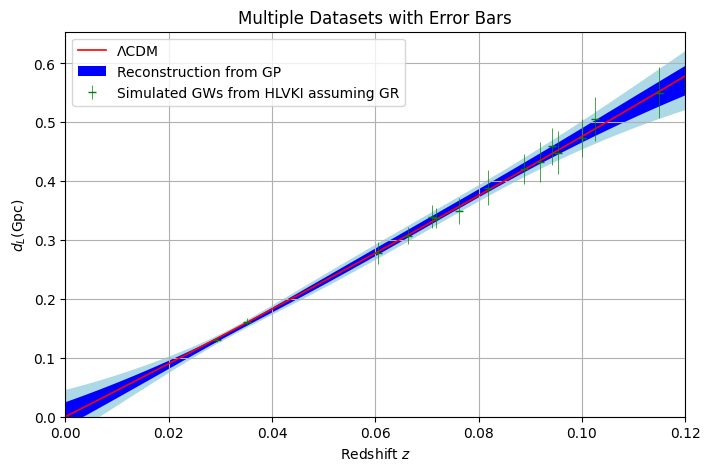


Optimized hyperparameters:
theta = [7.24679517e+02 1.87926961e-01]


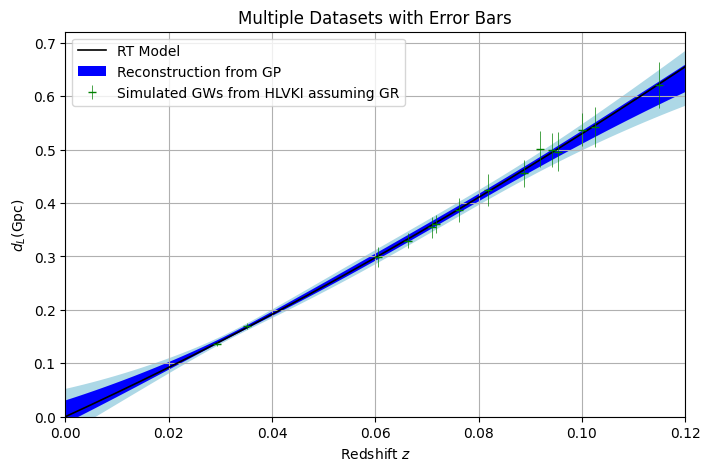

In [1367]:
plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.12, n_points=200), label='ΛCDM', linecolor='red')
plot_gapp(gapp_solve(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,1.0]), Label='Reconstruction from GP')
plot_spot_with_error(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming GR', fmt='_', color='green')
# plot_spot_with_error(read_csv_to_numpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming GR', fmt='_', color='green')

plot_show(xlimDOWN=0,xlimUP=0.12, xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(GW_forplot_RT(Xi=1.67, n=1.94, z_max=0.12, n_points=200), label='RT Model', linecolor='black')
plot_gapp(gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,1.0]), Label='Reconstruction from GP')
plot_spot_with_error(GT_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming GR', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12, xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)
